# Masking strategies

This notebook walks through every class in `shapiq.vision.masking` on one image and a fixed 2×2 player grid.

**Pixel space** (`PixelMaskingStrategy.apply`) rewrites absent regions before a CNN or pixel Hugging Face model runs.

* `MeanColorMasking` fills with the image mean color (default on ResNet and most pixel architectures)
* `ZeroMasking` fills with a constant, usually zero
* `BlurMasking` fills with a Gaussian-blurred copy of the image

**Latent space** (`LatentMaskingStrategy.predict_logits`) masks patch tokens inside a ViT forward pass via `bool_masked_pos`.

* `BoolMaskedPosStrategy` uses the Hugging Face masked-attention path
* `MaskTokenStrategy` zeros the mask-token embedding (default on `ViTArchitecture`)

The pixel section shows the masked images. The ViT section shows which tokens are absent and how the target-class probability changes for three coalitions.


In [1]:
from __future__ import annotations

from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from torchvision import transforms

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


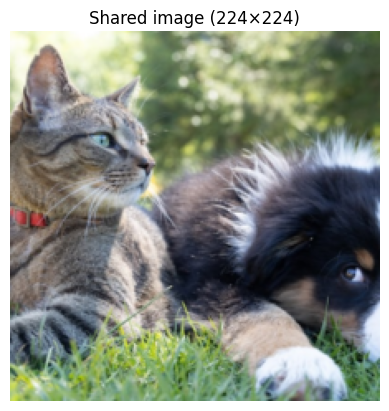

In [2]:
URL = (
    "https://images.unsplash.com/photo-1623387641168-d9803ddd3f35?"
    "q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0"
)
raw = Image.open(BytesIO(requests.get(URL, timeout=30).content)).convert("RGB")
resize = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
pil_image = resize(raw)
image = np.array(pil_image)

plt.imshow(image)
plt.title("Shared image (224×224)")
plt.axis("off")
plt.show()


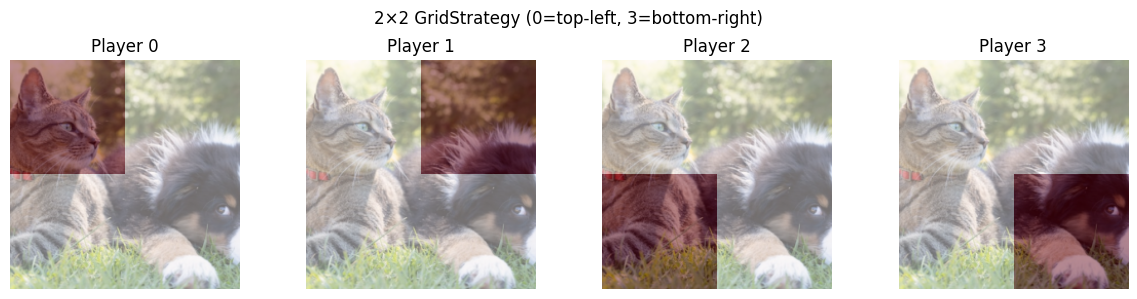

In [3]:
from shapiq.vision.players import GridStrategy

grid = GridStrategy(rows=2, cols=2)
player_masks = grid.get_masks(image)
H, W = image.shape[:2]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(image)
    ax.imshow(player_masks[i], alpha=0.45, cmap="Reds")
    ax.set_title(f"Player {i}")
    ax.axis("off")
plt.suptitle("2×2 GridStrategy (0=top-left, 3=bottom-right)")
plt.tight_layout()
plt.show()


## Pixel-space masking

Each row is one strategy. Columns are three coalitions on the same grid: everything visible, only the bottom-right player visible, and nothing visible.


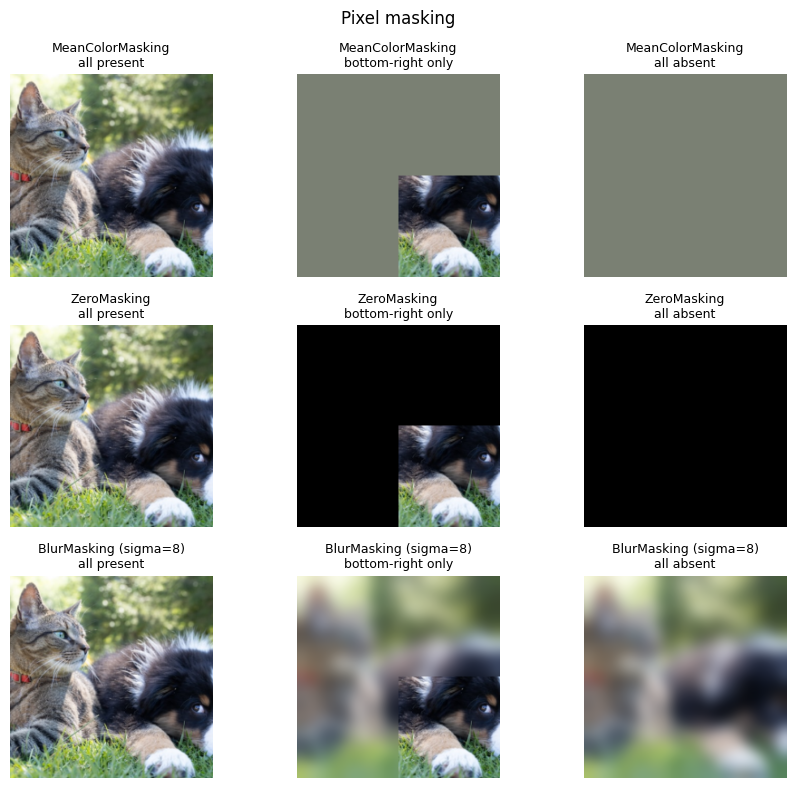

In [4]:
from shapiq.vision.masking import BlurMasking, MeanColorMasking, ZeroMasking

pixel_strategies = [
    ("MeanColorMasking", MeanColorMasking()),
    ("ZeroMasking", ZeroMasking()),
    ("BlurMasking (sigma=8)", BlurMasking(sigma=8)),
]

coalition_labels = [
    ("all present", np.array([[True, True, True, True]])),
    ("bottom-right only", np.array([[False, False, False, True]])),
    ("all absent", np.array([[False, False, False, False]])),
]

fig, axes = plt.subplots(len(pixel_strategies), len(coalition_labels), figsize=(9, 8))
for row, (name, strategy) in enumerate(pixel_strategies):
    batch = np.concatenate([coal for _, coal in coalition_labels], axis=0)
    masked = strategy.apply(image, player_masks, batch)
    for col, (coal_label, _) in enumerate(coalition_labels):
        ax = axes[row, col]
        ax.imshow(masked[col].astype(np.uint8))
        ax.set_title(f"{name}\n{coal_label}", fontsize=9)
        ax.axis("off")
plt.suptitle("Pixel masking")
plt.tight_layout()
plt.show()


## Latent-space masking (ViT)

Latent maskers keep the original pixels. They pass `bool_masked_pos` to the model, where `True` means the token is absent. The panels darken absent tokens. The bar chart uses the same three coalitions and the class ViT predicts on the full image.

On this crop the dog sits in the bottom-right quadrant, so `bottom-right only` keeps most of the class signal while `top-left only` would be near zero.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT target class: Bernese mountain dog


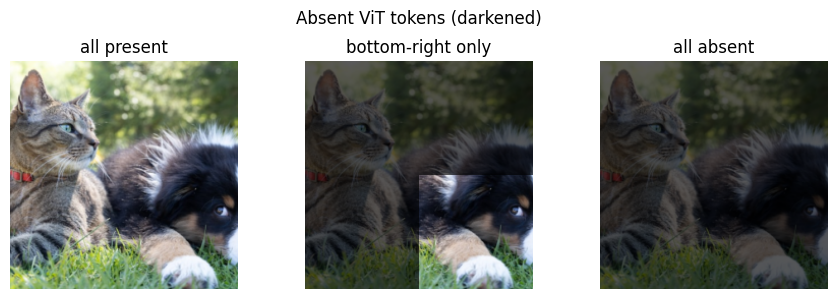

In [5]:
from transformers import ViTForImageClassification, ViTImageProcessor

from shapiq.vision.masking import BoolMaskedPosStrategy, MaskTokenStrategy
from shapiq.vision.players import PatchStrategy

vit_id = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(vit_id)
vit_model = ViTForImageClassification.from_pretrained(vit_id).eval().to(device)

grid_size = vit_model.config.image_size // vit_model.config.patch_size
patch_players = PatchStrategy(grid_size=grid_size, n_players=4)

inputs = processor(images=image, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)
with torch.no_grad():
    class_id = int(vit_model(pixel_values=pixel_values).logits.argmax(-1).item())
target_label = vit_model.config.id2label[class_id]
print("ViT target class:", target_label)


def latent_preview(coalition: np.ndarray) -> np.ndarray:
    bool_mask = patch_players.get_latent_mask(coalition).reshape(grid_size, grid_size).cpu().numpy()
    preview = image.astype(np.float64).copy()
    ph, pw = H // grid_size, W // grid_size
    for r in range(grid_size):
        for c in range(grid_size):
            if bool_mask[r, c]:
                y0, y1 = r * ph, (r + 1) * ph
                x0, x1 = c * pw, (c + 1) * pw
                preview[y0:y1, x0:x1] *= 0.35
    return preview.astype(np.uint8)


latent_coalitions = [
    ("all present", np.array([True, True, True, True])),
    ("bottom-right only", np.array([False, False, False, True])),
    ("all absent", np.array([False, False, False, False])),
]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (label, coal) in zip(axes, latent_coalitions, strict=False):
    ax.imshow(latent_preview(coal))
    ax.set_title(label)
    ax.axis("off")
plt.suptitle("Absent ViT tokens (darkened)")
plt.tight_layout()
plt.show()


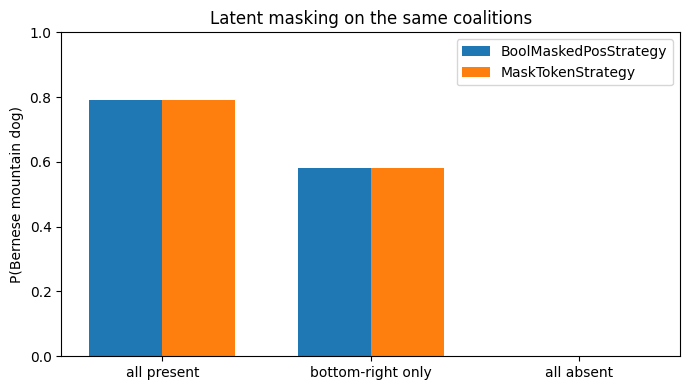

In [6]:
latent_strategies = [
    ("BoolMaskedPosStrategy", BoolMaskedPosStrategy()),
    ("MaskTokenStrategy", MaskTokenStrategy()),
]

x = np.arange(len(latent_coalitions))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))

for offset, (name, strategy) in enumerate(latent_strategies):
    probs = []
    for _, coal in latent_coalitions:
        bool_masks = patch_players.get_latent_mask(coal).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = strategy.predict_logits(vit_model, pixel_values, bool_masks)
            prob = torch.softmax(logits, dim=-1)[0, class_id].item()
        probs.append(prob)
    ax.bar(x + offset * width, probs, width=width, label=name)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([label for label, _ in latent_coalitions])
ax.set_ylabel(f"P({target_label})")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Latent masking on the same coalitions")
plt.tight_layout()
plt.show()
